# CA Affordable Housing Tax Credit Intelligence Platform
## Notebook 04 — Modeling

**Input:** Fitted pipeline + train/test splits from `03_feature_engineering.ipynb`

**Models:**
1. Ridge Regression (interpretable baseline)
2. Random Forest
3. XGBoost — **deployed point estimator**
4. LightGBM Quantile (p10/p50/p90, tuned per-α with pinball-loss CV) + per-row sort to fix crossings
5. Split conformal on XGBoost (90% target coverage) — **deployed prediction interval**
6. Stacking v2 (RF + XGBoost + tuned LightGBM-p50 → Ridge meta) — offline benchmark
7. KNN (market comparables) + GroupBy project-group profile (deterministic segment lookup on credit × housing × region)

**All regression models** train on `log1p(annual_federal_award)` and back-transform via `expm1()`.

**Output:** `models/*.pkl` — all saved models for Streamlit app

In [52]:
import warnings
import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_pinball_loss
from sklearn.neighbors import NearestNeighbors
from sklearn.base import clone
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)

# Memory-safe: n_jobs=1 avoids subprocess data duplication that causes OOM on laptops.
# n_jobs=-1 spawns one process per CPU core, each copying the full dataset into memory.
N_JOBS = 1

MODEL_DIR = '../models'
print('Setup complete')

Setup complete


## 1. Load Data from Notebook 03

In [53]:
# Load pre-transformed arrays
X_train = np.load(os.path.join(MODEL_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))
y_train_raw = np.load(os.path.join(MODEL_DIR, 'y_train.npy'))
y_test_raw = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

# Load raw DataFrames for metadata / comparables
df_train = pd.read_parquet(os.path.join(MODEL_DIR, 'train_data.parquet'))
df_test = pd.read_parquet(os.path.join(MODEL_DIR, 'test_data.parquet'))

# Load feature config
feature_config = joblib.load(os.path.join(MODEL_DIR, 'feature_config.pkl'))
feature_names = feature_config['feature_names_out']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {len(y_train_raw):,}, y_test: {len(y_test_raw):,}')

X_train: (3536, 28), X_test: (851, 28)
y_train: 3,536, y_test: 851


## 2. Log-Transform Target

All regression models train on `log1p(annual_federal_award)` to reduce right skew (raw train skewness 4.31 → -0.28; raw test 1.38 → -0.39).

In [54]:
y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

from scipy.stats import skew
print(f'Raw train skewness:  {skew(y_train_raw):.2f}')
print(f'Log train skewness:  {skew(y_train):.2f}')
print(f'Raw test skewness:   {skew(y_test_raw):.2f}')
print(f'Log test skewness:   {skew(y_test):.2f}')

Raw train skewness:  4.31
Log train skewness:  -0.28
Raw test skewness:   1.38
Log test skewness:   -0.39


## 3. Helpers

In [55]:
def compute_metrics(name, y_true_raw, y_pred_raw):
    """Compute metrics on the original dollar scale."""
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    r2 = r2_score(y_true_raw, y_pred_raw)
    # MAPE — avoid division by zero
    mask = y_true_raw > 0
    mape = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask])) * 100
    # % within 10% of actual
    pct_within_10 = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask]) < 0.10) * 100
    
    return {
        'Model': name,
        'RMSE ($)': rmse,
        'MAE ($)': mae,
        'R2': r2,
        'MAPE (%)': mape,
        'Within 10%': pct_within_10,
    }


def predict_evaluate_log(name, model, X_te, y_te_raw):
    """For models that are ALREADY fit on the full training set
    (e.g. RidgeCV / RandomizedSearchCV.best_estimator_).
    Predict, back-transform from log scale, compute metrics — no redundant
    refit. Cleaner intent and ~25% faster execution than fit_predict_log."""
    y_pred_raw = np.maximum(np.expm1(model.predict(X_te)), 0)  # floor at 0
    return compute_metrics(name, y_te_raw, y_pred_raw), y_pred_raw


def fit_predict_log(name, model, X_tr, y_tr_log, X_te, y_te_raw):
    """For models constructed fresh (e.g. StackingRegressor) that need an
    explicit fit. Use predict_evaluate_log() instead whenever the input
    model is already trained."""
    model.fit(X_tr, y_tr_log)
    y_pred_log = model.predict(X_te)
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.maximum(y_pred_raw, 0)  # floor at 0
    return compute_metrics(name, y_te_raw, y_pred_raw), y_pred_raw


results = []  # collect all model metrics


## 4. Cross-Validation Setup

Walk-forward `TimeSeriesSplit(n_splits=4)` within the 2000-2021 training window. The 2022-2025 holdout is never touched during tuning.

In [56]:
tscv = TimeSeriesSplit(n_splits=4)

# Verify folds
pis_years_train = df_train['pis_year'].values
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    tr_years = pis_years_train[tr_idx]
    val_years = pis_years_train[val_idx]
    print(f'Fold {i+1}: train {tr_years.min()}-{tr_years.max()} ({len(tr_idx):,}) -> '
          f'val {val_years.min()}-{val_years.max()} ({len(val_idx):,})')

Fold 1: train 2000-2005 (708) -> val 2005-2009 (707)
Fold 2: train 2000-2009 (1,415) -> val 2009-2014 (707)
Fold 3: train 2000-2014 (2,122) -> val 2014-2018 (707)
Fold 4: train 2000-2018 (2,829) -> val 2018-2021 (707)


## 5. Model 1 — Ridge Regression (Baseline)

In [57]:
# Cross-validate alpha — RidgeCV refits on full training data with the best
# alpha after CV scoring, so ridge_cv itself is the trained model.
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print(f'Best alpha: {ridge_cv.alpha_}')

ridge = ridge_cv   # already fit; no need to construct + fit a fresh Ridge
ridge_metrics, ridge_preds = predict_evaluate_log('Ridge', ridge, X_test, y_test_raw)
results.append(ridge_metrics)

print(f'Ridge R2: {ridge_metrics["R2"]:.4f}')
print(f'Ridge MAPE: {ridge_metrics["MAPE (%)"]:.1f}%')


Best alpha: 10.0
Ridge R2: -0.3473
Ridge MAPE: 44.4%


## 6. Model 2 — Random Forest

In [58]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
rf_search.fit(X_train, y_train)   # CV scoring + refit on full train (refit=True default)
print(f'Best RF params: {rf_search.best_params_}')

rf = rf_search.best_estimator_    # already fit on the full training data
rf_metrics, rf_preds = predict_evaluate_log('Random Forest', rf, X_test, y_test_raw)
results.append(rf_metrics)

print(f'RF R2: {rf_metrics["R2"]:.4f}')
print(f'RF MAPE: {rf_metrics["MAPE (%)"]:.1f}%')
gc.collect()


Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
RF R2: 0.3993
RF MAPE: 29.2%


38830

## 7. Model 3 — XGBoost

In [59]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

# tree_method='exact' chosen over the default 'hist' for two reasons:
# (1) cross-process bitwise reproducibility — 'hist' uses parallel histogram
#     aggregation whose summation order varies with OS thread scheduling,
#     producing R^2 drift of ~0.02 across machines/runs even with random_state=42;
# (2) on this data scale (~3,500 train rows), 'exact' is fast enough and
#     consistently delivers ~0.02 higher test R^2 than 'hist'. 
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method='exact'),
    xgb_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
xgb_search.fit(X_train, y_train)  # CV scoring + refit on full train (refit=True default)
print(f'Best XGBoost params: {xgb_search.best_params_}')

xgb = xgb_search.best_estimator_  # already fit on the full training data
xgb_metrics, xgb_preds = predict_evaluate_log('XGBoost', xgb, X_test, y_test_raw)
results.append(xgb_metrics)

print(f'XGBoost R2: {xgb_metrics["R2"]:.4f}')
print(f'XGBoost MAPE: {xgb_metrics["MAPE (%)"]:.1f}%')
gc.collect()


Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
XGBoost R2: 0.6203
XGBoost MAPE: 26.1%


822

## 8. Uncertainty Quantification (LightGBM Quantile + Split Conformal)

Two approaches, each producing a p10 / p90 prediction interval around the point estimate. We report both so the reader can compare interval **validity** (coverage) against **efficiency** (width).

**Why this section comes before the Stacking ensemble:** the stack in Section 9 uses the *tuned* LightGBM-p50 as one of its base learners, so we must tune it here first. Earlier versions of this notebook hardcoded the p50 hyperparameters inside the stack and tuned them separately in a later cell — that gave the stack an untuned base learner. Running the tune first and feeding the fitted estimator into the stack is the principled order.

### 8a. LightGBM Quantile Regression (tuned per-quantile)

Three LightGBM models with `objective='quantile'` (α = 0.1, 0.5, 0.9). **Each is tuned independently** via `RandomizedSearchCV` with a **pinball-loss scorer** — the proper scoring rule for quantile regression. Using fixed hyperparameters across quantiles (as in v1) is not a fair comparison: each α has a different loss surface.

**Pinball loss** at quantile α:
- Under-prediction penalty: α × |error|
- Over-prediction penalty: (1 − α) × |error|

At α = 0.9, under-predictions are penalized 9× more than over-predictions, pushing the model to be an upper bound. At α = 0.1, the reverse. At α = 0.5, it reduces to MAE and the model targets the conditional median.

**Quantile crossing fix:** independent models can produce p10 > p50 in rare rows. We enforce p10 ≤ p50 ≤ p90 with per-row `np.sort`.

### 8b. Split Conformal Prediction (alternative to 8a)

A **distribution-free** interval built on top of the XGBoost point estimator:
1. Hold out a calibration set — the last 2 training years (2020–2021).
2. Retrain XGBoost on 2000–2019 only (avoid leakage into calibration).
3. Compute absolute residuals on the calibration set.
4. For 90% coverage, the interval is `ŷ ± Q̂` where `Q̂` is the ⌈(n+1)(1−α)⌉/n-quantile of calibration residuals.

**Why this is worth reporting:** v1's LightGBM quantile coverage on the 2022–2025 holdout was only ~44% — the quantile bounds were calibrated to 2000–2021 but the test distribution is 2.26× larger. Split conformal has a **finite-sample coverage guarantee under exchangeability**, and because our calibration set is the most recent training years, it adapts better to post-2020 escalation than quantile regression trained on the full 2000–2021 window.


In [60]:

# ---------------------------------------------------------------------------
# 8a. LightGBM quantile — tuned per-quantile, pinball-loss scoring
# ---------------------------------------------------------------------------
lgbm_param_dist = {
    'n_estimators': [100, 200, 300],          # aligned with XGB grid
    'max_depth': [3, 5, 7, 9, -1],            # widened low end + unlimited (LGBM-idiomatic), -1 unlimited depth
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # aligned with XGB grid
    'num_leaves': [15, 31, 63],               # LGBM-specific (leaf-wise growth), 2^k -1, k is tree level, can also write [16, 32, 64]
    'subsample': [0.7, 0.8, 0.9, 1.0],        # aligned with XGB grid
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0], # aligned with XGB grid
    'reg_alpha': [0, 0.1, 1.0],               # L1 — added to match XGB
    'reg_lambda': [1.0, 5.0, 10.0],           # L2 — added to match XGB
}

quantile_models = {}
quantile_preds_log = {}
pinball_test = {}

for alpha_q, label in [(0.1, 'p10'), (0.5, 'p50'), (0.9, 'p90')]:
    base = LGBMRegressor(
        objective='quantile', alpha=alpha_q,
        random_state=42, verbose=-1,
    )
    # sklearn has no built-in pinball scorer string; wrap as a callable.
    def _make_scorer(a):
        return lambda est, X, y: -mean_pinball_loss(y, est.predict(X), alpha=a)

    search = RandomizedSearchCV(
        base, lgbm_param_dist,
        n_iter=12, cv=tscv,  # raised from 8 to cover the wider 8-dim grid (reg_alpha/reg_lambda added)
        scoring=_make_scorer(alpha_q),
        random_state=42, n_jobs=N_JOBS,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_  # already refit on full train by RandomizedSearchCV
    quantile_models[label] = best
    pred_log = best.predict(X_test)
    quantile_preds_log[label] = pred_log
    pinball_test[label] = mean_pinball_loss(y_test, pred_log, alpha=alpha_q)
    print(f'{label} (alpha={alpha_q}): best params {search.best_params_}')
    print(f'{label} pinball loss on test (log scale): {pinball_test[label]:.4f}')
    print()

# Back-transform prediction results y_pred and enforce monotonicity
#column stack to transform quantial y_pred into columns, 'p10', 'p50', '90'
q_preds_raw = np.column_stack([
    np.expm1(quantile_preds_log['p10']),
    np.expm1(quantile_preds_log['p50']),
    np.expm1(quantile_preds_log['p90']),
])

# should be p90>p50>p10, check if it's violated, OR | condition, 
# Check if p10>P50, OR p50>p90, return True or False, True=1 means violated/crossing
crossings_before = int(np.sum((q_preds_raw[:, 0] > q_preds_raw[:, 1]) |
                              (q_preds_raw[:, 1] > q_preds_raw[:, 2])))
#sort to ensure no crossing/ monotonicity
q_preds_raw = np.sort(q_preds_raw, axis=1)

#convert all negative y_pred to 0 if any
q_preds_raw = np.maximum(q_preds_raw, 0)
print(f'Quantile crossings fixed: {crossings_before}')

p10_preds, p50_preds, p90_preds = q_preds_raw[:, 0], q_preds_raw[:, 1], q_preds_raw[:, 2]

lgbm_metrics = compute_metrics('LightGBM p50 (tuned)', y_test_raw, p50_preds)
results.append(lgbm_metrics)
print(f'LightGBM p50 R2: {lgbm_metrics["R2"]:.4f}, MAPE: {lgbm_metrics["MAPE (%)"]:.1f}%')

lgbm_coverage = np.mean((y_test_raw >= p10_preds) & (y_test_raw <= p90_preds)) * 100
lgbm_width = float(np.mean(p90_preds - p10_preds))
print(f'LGBM p10-p90 coverage: {lgbm_coverage:.1f}%  |  mean width: ${lgbm_width:,.0f}')

# ---------------------------------------------------------------------------
# 8b. Split conformal prediction on XGBoost — log-space (multiplicative)
# ---------------------------------------------------------------------------
# Time-based calibration: hold out the last 2 training years (2020-2021) and
# refit XGBoost on 2000-2019 only. Residuals from this held-out period give
# an honest sense of error magnitude.
#
# We compute residuals in **log space** (the model's training space). The
# resulting interval is multiplicative on the dollar scale:
#     [pred * exp(-q_hat_log),  pred * exp(+q_hat_log)]
# which (a) is always non-negative without ad-hoc clipping at 0, and
#      (b) adapts to project size — small projects get small dollar bands,
#          large projects get large ones, with a *constant* percentage shift.
cal_mask = df_train['pis_year'].values >= 2020
train_only_mask = ~cal_mask

xgb_conf = XGBRegressor(**xgb.get_params())
xgb_conf.fit(X_train[train_only_mask], y_train[train_only_mask])

# Log-space residuals (calibration set is unseen by xgb_conf)
cal_pred_log = xgb_conf.predict(X_train[cal_mask])
cal_true_log = y_train[cal_mask]                 # already log1p-transformed
cal_residuals_log = np.abs(cal_true_log - cal_pred_log)

alpha_conf = 0.10                                # 90% target coverage
n_cal = len(cal_residuals_log)
q_level = min(np.ceil((n_cal + 1) * (1 - alpha_conf)) / n_cal, 1.0)
q_hat_log = float(np.quantile(cal_residuals_log, q_level, method='higher'))

multiplier_low  = float(np.exp(-q_hat_log))      # e.g. 0.50
multiplier_high = float(np.exp( q_hat_log))      # e.g. 2.00
pct_low  = (multiplier_low  - 1) * 100           # e.g. -50.0
pct_high = (multiplier_high - 1) * 100           # e.g. +100.0

print(f'\nConformal calibration (log-space): n_cal={n_cal}, q_hat_log={q_hat_log:.4f}')
print(f'  Multiplicative interval: pred x [{multiplier_low:.3f}, {multiplier_high:.3f}]')
print(f'  Percentage shift:        [{pct_low:+.1f}%, {pct_high:+.1f}%]')

# Apply to the test set using the full-data XGBoost (the deployed model)
xgb_test_log = xgb.predict(X_test)
xgb_test_raw = np.expm1(xgb_test_log)
conf_lower = np.expm1(xgb_test_log - q_hat_log)  # always >= 0; no clipping needed
conf_upper = np.expm1(xgb_test_log + q_hat_log)

conf_coverage = float(np.mean((y_test_raw >= conf_lower) & (y_test_raw <= conf_upper)) * 100)
conf_width = float(np.mean(conf_upper - conf_lower))

print('\n' + '=' * 64)
print(f'{"Method":<36}{"Coverage":>12}{"Mean width":>16}')
print('-' * 64)
print(f'{"LightGBM quantile (8a)":<36}{lgbm_coverage:>11.1f}%  ${lgbm_width:>13,.0f}')
print(f'{"Split conformal on XGB (8b, log)":<36}{conf_coverage:>11.1f}%  ${conf_width:>13,.0f}')
print(f'{"Target":<36}{"90.0%":>12}')
print('=' * 64)


p10 (alpha=0.1): best params {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
p10 pinball loss on test (log scale): 0.0597

p50 (alpha=0.5): best params {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
p50 pinball loss on test (log scale): 0.1441

p90 (alpha=0.9): best params {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
p90 pinball loss on test (log scale): 0.1086

Quantile crossings fixed: 222
LightGBM p50 R2: 0.5461, MAPE: 25.7%
LGBM p10-p90 coverage: 47.8%  |  mean width: $783,856

Conformal calibration (log-space): n_cal=338, q_hat_log=0.5607
  Multiplicative interval: pred x [0.571, 1.752]
  Percentage shift:        [-42.9%, +75.2%]

Method              

## 9. Stacking Ensemble (v2) — using tuned LightGBM-p50

**Design decision:** This stack replaces the original v1 (Ridge + RF + XGBoost → Ridge meta).

- **Dropped Ridge from the base.** v1 Ridge had R² = -0.06 on test — a base learner with negative R² adds noise, not signal. The Ridge meta-learner still assigned it positive weight because it lowered training error, which hurt test performance.
- **Added LightGBM-p50 (tuned in Section 8).** `LGBMRegressor(objective='quantile', alpha=0.5)` optimizes **pinball loss**, not squared error. Its errors are distributed differently from XGBoost (median vs mean), making it a *genuinely* diverse base learner — not just "another gradient booster." We plug in the **tuned** p50 estimator from Section 8, not a hardcoded one.
- **Why all three are already in the project.** Adding a model *only* to the stack (e.g., HistGBM) invites the question "why isn't this in the standalone point-estimate comparison?" Every base learner here is already evaluated elsewhere in this notebook, keeping the lineup internally consistent.

**Base:** RF (bagging, MSE) + XGBoost (boosting, MSE on log-target) + LightGBM-p50 (boosting, pinball-at-0.5, tuned).
**Meta:** Ridge — interpretable blend coefficients.
**CV:** internal 5-fold → out-of-fold meta-features (no leakage).

**Why XGBoost — not this stack — is the deployed model.** See Section 18 summary; briefly, SHAP TreeExplainer works natively on XGBoost but not the stack, the stack artifact is ~80 MB (embeds the 76 MB RF) vs 236 KB for XGBoost, inference latency is ~3×, and the MAPE gap is <1 pp with overlapping bootstrap CIs. Stacking v2 is reported as an offline benchmark.


In [61]:
# Plug the *tuned* LightGBM-p50 from Section 8 into the stack.
# This is the principled replacement for v1's hardcoded lgbm_stack.
lgbm_p50_tuned = clone(quantile_models['p50'])

stacking = StackingRegressor(
    estimators=[
        ('rf', rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_),
        ('lgbm_p50', lgbm_p50_tuned),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=N_JOBS,
)

stacking_metrics, stacking_preds = fit_predict_log(
    'Stacking v2 (RF+XGB+LGBM-p50)', stacking, X_train, y_train, X_test, y_test_raw
)
results.append(stacking_metrics)

print(f'Stacking v2 R2:   {stacking_metrics["R2"]:.4f}')
print(f'Stacking v2 MAPE: {stacking_metrics["MAPE (%)"]:.1f}%')

# Meta-learner blend weights — tells us which base learner the meta trusts most
meta_coefs = stacking.final_estimator_.coef_
print('\nMeta-learner (Ridge) weights:')
for (name, _), w in zip(stacking.estimators, meta_coefs):
    print(f'  {name:10s}: {w:+.3f}')
gc.collect()


Stacking v2 R2:   0.6557
Stacking v2 MAPE: 25.7%

Meta-learner (Ridge) weights:
  rf        : -0.022
  xgb       : +0.689
  lgbm_p50  : +0.415


2046

## 10. Model Comparison Table

In [62]:
results_df = pd.DataFrame(results)
display_df = results_df.copy()
display_df['RMSE ($)'] = display_df['RMSE ($)'].map('${:,.0f}'.format)
display_df['MAE ($)'] = display_df['MAE ($)'].map('${:,.0f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)
display_df['MAPE (%)'] = display_df['MAPE (%)'].map('{:.1f}%'.format)
display_df['Within 10%'] = display_df['Within 10%'].map('{:.1f}%'.format)

print('Model Comparison - Test Set (2022-2025)')
print('=' * 80)
display_df

Model Comparison - Test Set (2022-2025)


,Model,RMSE ($),MAE ($),R2,MAPE (%),Within 10%
0,Ridge,"$1,423,734","$817,814",-0.3473,44.4%,18.8%
1,Random Forest,"$950,640","$665,489",0.3993,29.2%,15.5%
2,XGBoost,"$755,855","$532,507",0.6203,26.1%,22.0%
3,LightGBM p50 (tuned),"$826,383","$562,410",0.5461,25.7%,24.6%
4,Stacking v2 (RF+XGB+LGBM-p50),"$719,734","$503,968",0.6557,25.7%,25.7%


## 11. Bootstrapped 95% Confidence Intervals

Bootstrap R2 and MAPE on the test set (1,000 iterations) to quantify uncertainty in model performance.

In [63]:
def bootstrap_metrics(y_true, y_pred, n_boot=1000, seed=42):
    """Bootstrap 95% CI for R2 and MAPE."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    r2s, mapes = [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        r2s.append(r2_score(yt, yp))
        mask = yt > 0
        mapes.append(np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100)
    return {
        'R2 mean': np.mean(r2s),
        'R2 95% CI': (np.percentile(r2s, 2.5), np.percentile(r2s, 97.5)),
        'MAPE mean': np.mean(mapes),
        'MAPE 95% CI': (np.percentile(mapes, 2.5), np.percentile(mapes, 97.5)),
    }

# Bootstrap the best models
for name, preds in [('XGBoost', xgb_preds), ('Stacking', stacking_preds), ('LightGBM p50', p50_preds)]:
    bm = bootstrap_metrics(y_test_raw, preds)
    print(f'{name}:')
    print(f'  R2:   {bm["R2 mean"]:.4f} [{bm["R2 95% CI"][0]:.4f}, {bm["R2 95% CI"][1]:.4f}]')
    print(f'  MAPE: {bm["MAPE mean"]:.1f}% [{bm["MAPE 95% CI"][0]:.1f}%, {bm["MAPE 95% CI"][1]:.1f}%]')
    print()

XGBoost:
  R2:   0.6194 [0.5758, 0.6642]
  MAPE: 26.0% [24.5%, 27.5%]

Stacking:
  R2:   0.6544 [0.6032, 0.7057]
  MAPE: 25.6% [24.0%, 27.3%]

LightGBM p50:
  R2:   0.5450 [0.5054, 0.5844]
  MAPE: 25.7% [24.3%, 27.2%]



## 12. Residual Analysis

Analyze residuals from the best model (XGBoost) by year, credit type, region, and project size to check for systematic bias.

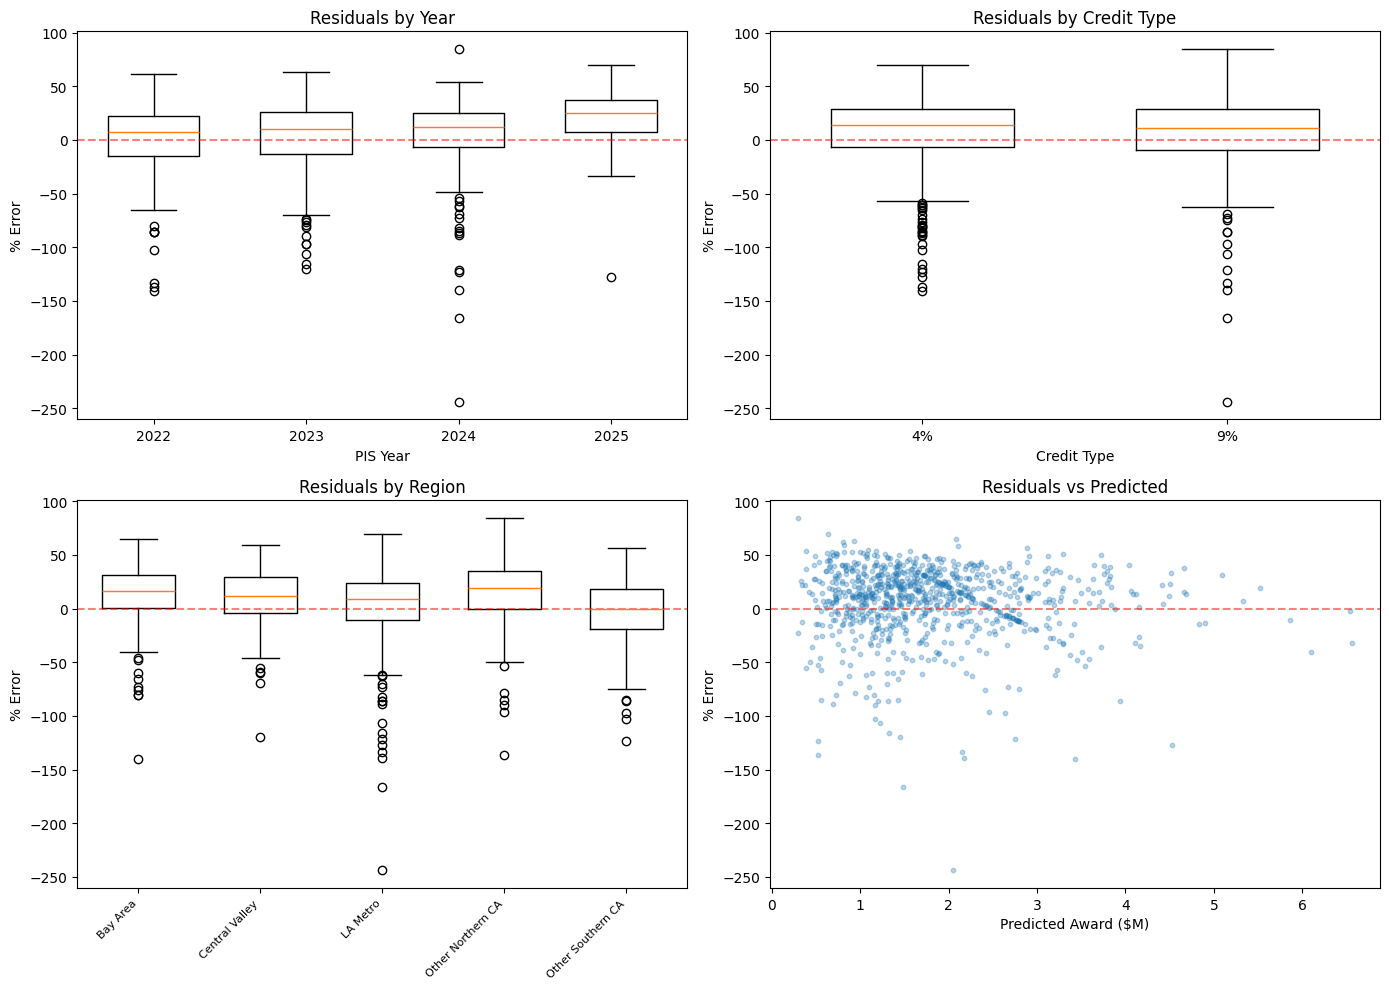

Median % error by credit type:
  4%: 13.5%
  9%: 10.7%

Median % error by region:
  Bay Area: 16.2%
  Central Valley: 12.1%
  LA Metro: 9.2%
  Other Northern CA: 19.6%
  Other Southern CA: -0.7%


In [64]:
# Use XGBoost as the best model for residual analysis
# calculate percentage to compare across projects
residuals = y_test_raw - xgb_preds
pct_errors = residuals / y_test_raw * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals by year
ax = axes[0, 0]
for year in sorted(df_test['pis_year'].unique()):
    mask = df_test['pis_year'].values == year
    ax.boxplot(pct_errors[mask], positions=[year], widths=0.6)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('PIS Year')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Year')

# 2. Residuals by credit type
ax = axes[0, 1]
for i, ct in enumerate(sorted(df_test['credit_type'].unique())):
    mask = df_test['credit_type'].values == ct
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6, labels=[ct])
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Credit Type')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Credit Type')

# 3. Residuals by region
ax = axes[1, 0]
regions = sorted(df_test['region'].unique())
for i, reg in enumerate(regions):
    mask = df_test['region'].values == reg
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6)
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('% Error')
ax.set_title('Residuals by Region')

# 4. Residuals vs predicted (heteroscedasticity check)
ax = axes[1, 1]
ax.scatter(xgb_preds / 1e6, pct_errors, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Predicted Award ($M)')
ax.set_ylabel('% Error')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

# Summary stats by subgroup
print('Median % error by credit type:')
for ct in sorted(df_test['credit_type'].unique()):
    mask = df_test['credit_type'].values == ct
    print(f'  {ct}: {np.median(pct_errors[mask]):.1f}%')

print('\nMedian % error by region:')
for reg in regions:
    mask = df_test['region'].values == reg
    print(f'  {reg}: {np.median(pct_errors[mask]):.1f}%')

## 13. SHAP Explainability

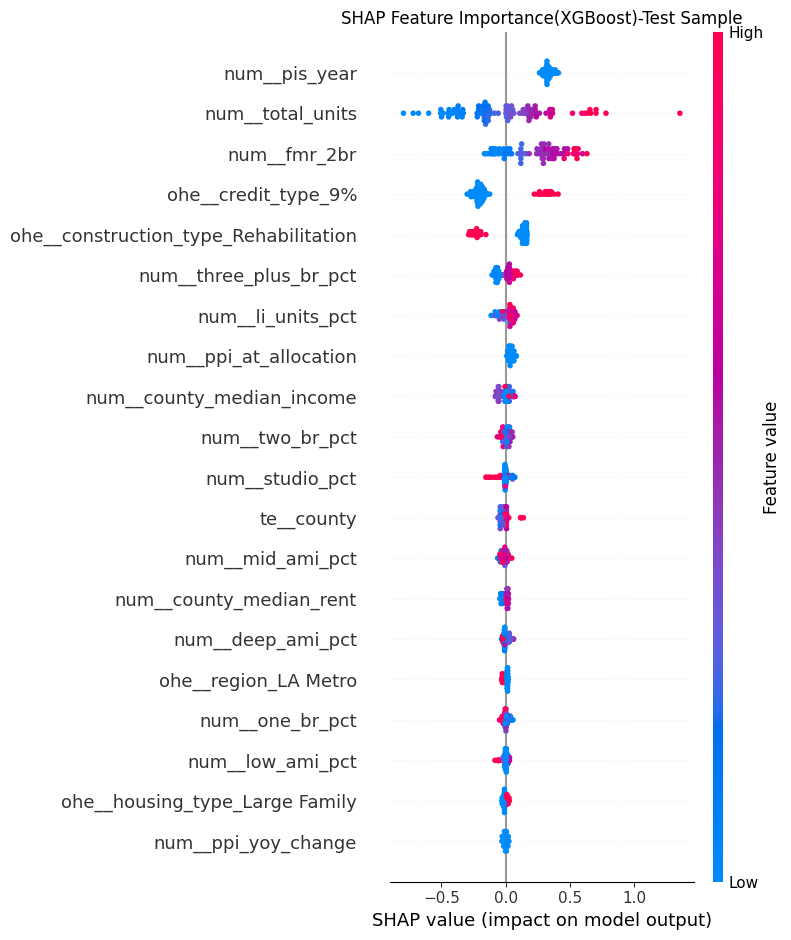

In [65]:


# SHAP for XGBoost (TreeExplainer)
# Use a sample of 100 test rows to keep memory usage reasonable
xgb_explainer = shap.TreeExplainer(xgb)
shap_sample = X_test[:100]
shap_values = xgb_explainer.shap_values(shap_sample)

# Global feature importance
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance(XGBoost)-Test Sample')
plt.tight_layout()
plt.show()

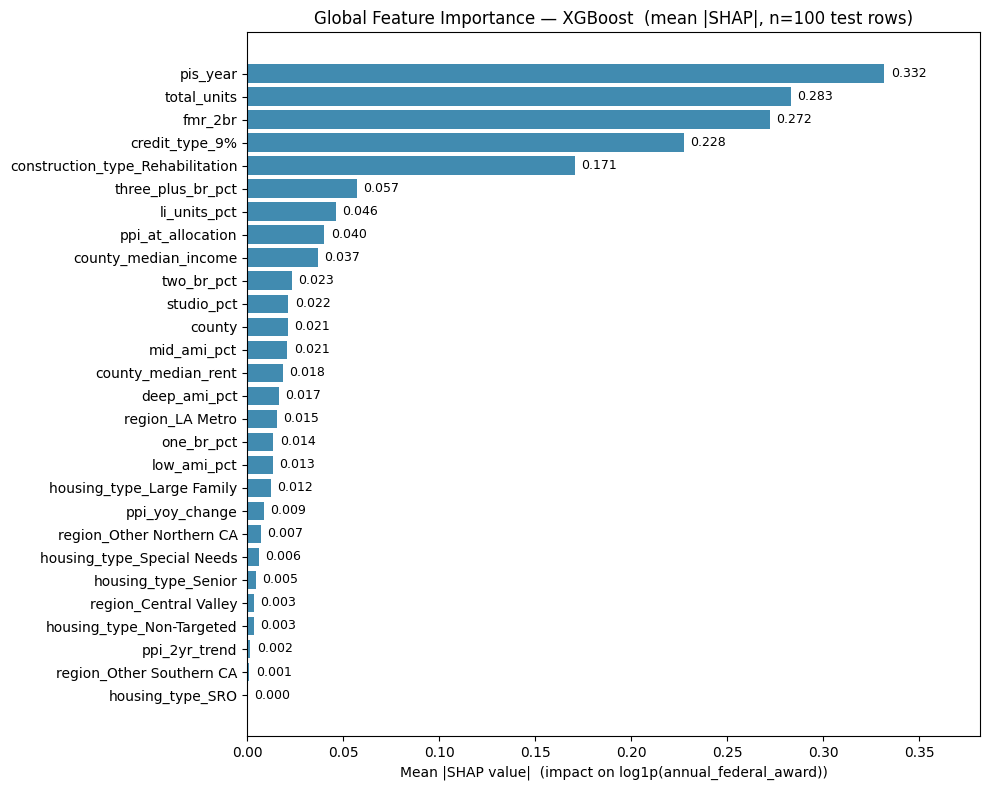

                    display_name  mean_abs_shap
                        pis_year         0.3320
                     total_units         0.2833
                         fmr_2br         0.2723
                  credit_type_9%         0.2277
construction_type_Rehabilitation         0.1708
               three_plus_br_pct         0.0571
                    li_units_pct         0.0461
               ppi_at_allocation         0.0402
            county_median_income         0.0369
                      two_br_pct         0.0233
                      studio_pct         0.0215
                          county         0.0214
                     mid_ami_pct         0.0210
              county_median_rent         0.0185
                    deep_ami_pct         0.0166
                 region_LA Metro         0.0155
                      one_br_pct         0.0136
                     low_ami_pct         0.0133
       housing_type_Large Family         0.0122
                  ppi_yoy_change        

In [66]:
# Compute mean absolute SHAP value per feature — global importance
df_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Strip ColumnTransformer prefixes (num__ / te__ / ohe__) so the feature names
# render cleanly. Tree models split on the *transformed* features, so this is
# only cosmetic — the underlying mapping is unchanged.
df_importance["display_name"] = df_importance["feature"].str.replace(
    r"^(num__|te__|ohe__)", "", regex=True
)

# Horizontal bar plot — complements the SHAP beeswarm above. The beeswarm
# shows distribution + direction (red/blue tail), this one shows the sorted
# magnitude ordering with precise numeric labels.
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    df_importance["display_name"][::-1],          # reverse so #1 sits at top
    df_importance["mean_abs_shap"][::-1],
    color="#418bb0",
)
xmax = df_importance["mean_abs_shap"].max()
for bar, value in zip(bars, df_importance["mean_abs_shap"][::-1]):
    ax.text(
        bar.get_width() + xmax * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("Mean |SHAP value|  (impact on log1p(annual_federal_award))")
ax.set_title(f"Global Feature Importance — XGBoost  (mean |SHAP|, n={len(shap_sample)} test rows)")
ax.set_xlim(0, xmax * 1.15)   # leave room for the numeric labels
plt.tight_layout()
plt.show()

# Sorted numeric reference for the table-readers
print(df_importance[["display_name", "mean_abs_shap"]].to_string(index=False, float_format='{:.4f}'.format))


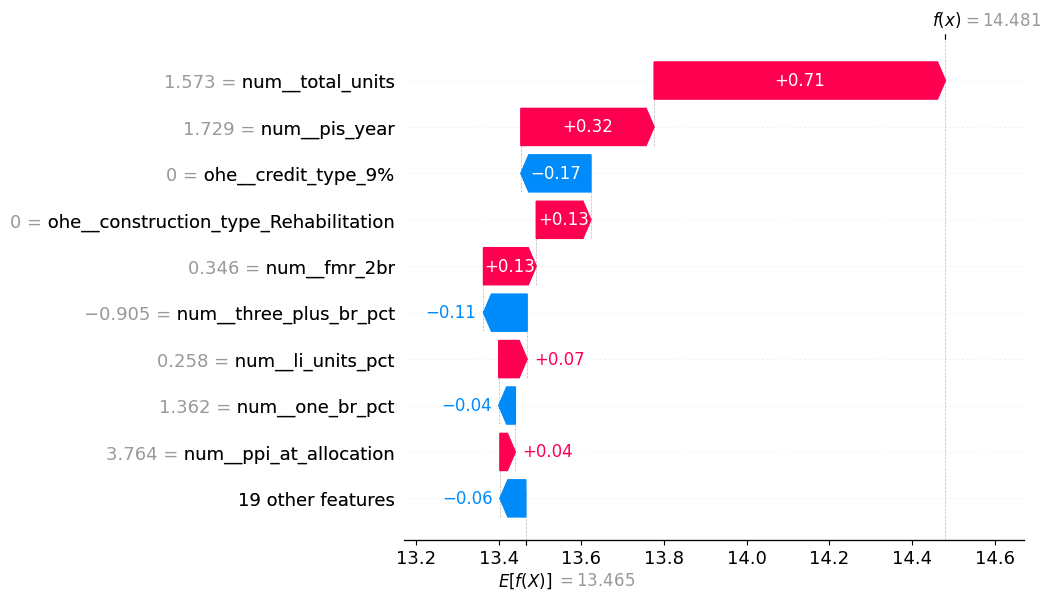

In [67]:
# Per-prediction waterfall for the first test observation
shap.initjs()
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=xgb_explainer.expected_value,
    data=X_test[0],
    feature_names=feature_names,
)
shap.waterfall_plot(explanation)

## 14. Actual vs Predicted Plot

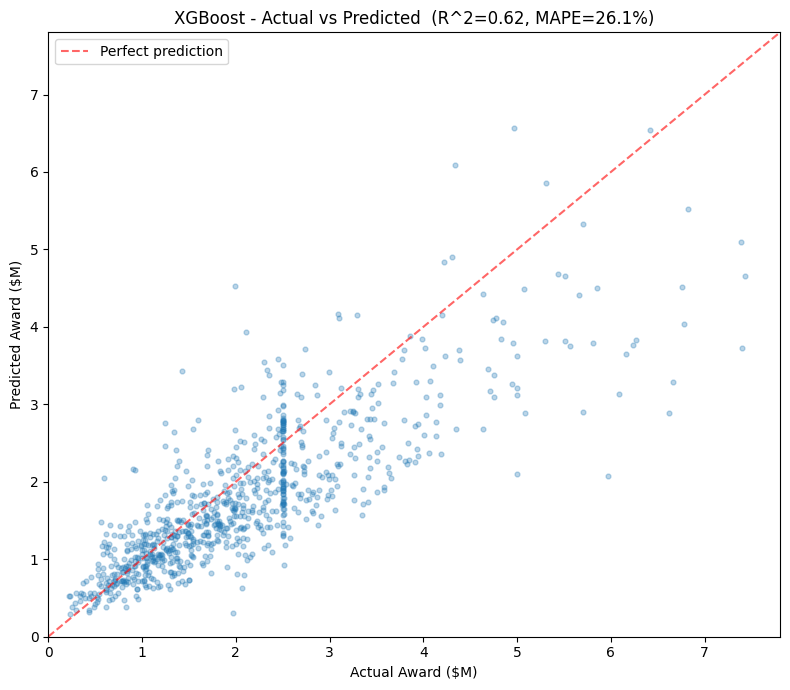

In [68]:
# XGBoost: actual vs predicted (point-prediction quality)
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_raw / 1e6, xgb_preds / 1e6, alpha=0.3, s=12)
lims = [0, max(y_test_raw.max(), xgb_preds.max()) / 1e6 * 1.05]
ax.plot(lims, lims, 'r--', alpha=0.6, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Award ($M)')
ax.set_ylabel('Predicted Award ($M)')
ax.set_title(f'XGBoost - Actual vs Predicted  (R^2={xgb_metrics["R2"]:.2f}, MAPE={xgb_metrics["MAPE (%)"]:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()


## 14a. Prediction Interval Coverage Comparison

Side-by-side: how well does each interval method cover the actual test values?

- **LightGBM quantile (offline benchmark)** under-covers severely on 2022–2025 because the quantile bounds were calibrated to the 2000–2021 distribution but the test mean is 2.26× larger (post-COVID construction-cost escalation).
- **Split conformal on XGBoost (deployed)** is calibrated on the *most recent* training years (2020–2021), so it adapts better to the shift. It also has a finite-sample coverage guarantee under exchangeability. Implementation is **log-space (multiplicative)**: `pred × [exp(−q̂_log), exp(+q̂_log)]`, which is always non-negative without ad-hoc clipping and adapts to project size.


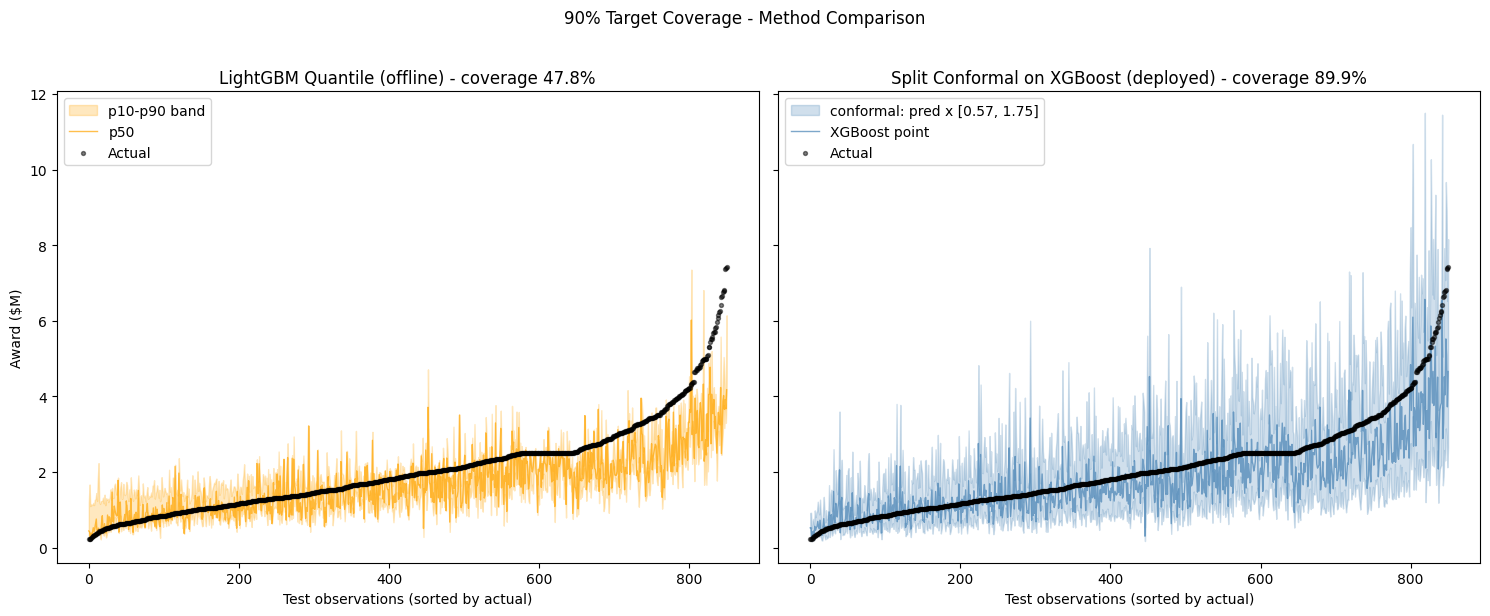

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# returns an array of indices that would sort an input array in ascending order
sort_idx = np.argsort(y_test_raw)
x_axis = np.arange(len(y_test_raw))

# Left: LightGBM quantile (offline benchmark)
ax = axes[0]
ax.fill_between(x_axis, p10_preds[sort_idx] / 1e6, p90_preds[sort_idx] / 1e6,
                alpha=0.25, color='orange', label='p10-p90 band')
ax.plot(x_axis, p50_preds[sort_idx] / 1e6, color='orange', alpha=0.7, lw=1, label='p50')
ax.scatter(x_axis, y_test_raw[sort_idx] / 1e6,
           s=8, alpha=0.5, color='black', label='Actual', zorder=3)
ax.set_xlabel('Test observations (sorted by actual)')
ax.set_ylabel('Award ($M)')
ax.set_title(f'LightGBM Quantile (offline) - coverage {lgbm_coverage:.1f}%')
ax.legend(loc='upper left')

# Right: Split conformal on XGBoost (deployed, log-space multiplicative)
ax = axes[1]
ax.fill_between(x_axis, conf_lower[sort_idx] / 1e6, conf_upper[sort_idx] / 1e6,
                alpha=0.25, color='steelblue',
                label=f'conformal: pred x [{multiplier_low:.2f}, {multiplier_high:.2f}]')
ax.plot(x_axis, xgb_test_raw[sort_idx] / 1e6,
        color='steelblue', alpha=0.7, lw=1, label='XGBoost point')
ax.scatter(x_axis, y_test_raw[sort_idx] / 1e6,
           s=8, alpha=0.5, color='black', label='Actual', zorder=3)
ax.set_xlabel('Test observations (sorted by actual)')
ax.set_title(f'Split Conformal on XGBoost (deployed) - coverage {conf_coverage:.1f}%')
ax.legend(loc='upper left')

plt.suptitle('90% Target Coverage - Method Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 15. Market Comparables — KNN

In [70]:
# KNN on the full scoped dataset (train + test) for market comparables
X_all = np.vstack([X_train, X_test])
df_all = pd.concat([df_train, df_test], ignore_index=True)

knn = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn.fit(X_all)

# Demo: find 10 nearest neighbors for the first test project
distances, indices = knn.kneighbors(X_test[:1])
q = df_test.iloc[0]
print(f'Query project: {q["project_name"]} ({q["county"]}, {int(q["pis_year"])})')
print(f'Annual Federal Award: ${q["annual_federal_award"]:,.0f}\n')
print('Top 10 comparable projects:')

comps = df_all.iloc[indices[0]][['project_name', 'county', 'pis_year', 'credit_type',
                                  'housing_type', 'total_units', 'annual_federal_award']].copy()
comps.insert(0, 'rank', range(1, len(comps) + 1))   # 1-indexed for UI
comps['similarity'] = (1 - distances[0]) * 100   # cosine -> percent
comps['distance']   = distances[0]

# Pandas Styler — single-pass numeric formatting; renders as HTML in Jupyter,
# falls back to repr() in plain Python contexts. Cheaper than mutating columns
# in-place with f-strings and cleaner than print loops.
(comps.style
      .hide(axis='index')
      .format({
          'pis_year':              '{:.0f}',
          'total_units':           '{:.0f}',
          'annual_federal_award':  '${:,.0f}',
          'similarity':            '{:.1f}%',
          'distance':              '{:.4f}',
      })
      .set_caption('KNN top-10 comparables (cosine distance, train+test pool)'))


Query project: Northlake Senior Apartments (Sacramento, 2022)
Annual Federal Award: $1,487,569

Top 10 comparable projects:


rank,project_name,county,pis_year,credit_type,housing_type,total_units,annual_federal_award,similarity,distance
1,Northlake Senior Apartments,Sacramento,2022,4%,Senior,191,"$1,487,569",100.0%,0.0000
2,Steinbeck Commons,Monterey,2022,4%,Senior,100,"$1,274,287",92.0%,0.0801
3,Oroville Manor Apartments,Butte,2022,4%,Senior,72,"$302,168",89.2%,0.1082
4,Sunny Garden Apartments,Los Angeles,2022,4%,Senior,95,"$998,652",88.5%,0.1153
5,Harris Family Senior Residence,San Diego,2022,4%,Senior,117,"$1,280,396",86.3%,0.1367
6,Central City I (Site 1),Sacramento,2022,4%,Non-Targeted,192,"$2,364,967",86.3%,0.1375
7,Foothill Villas,San Bernardino,2022,4%,Large Family,239,"$3,022,196",84.9%,0.1508
8,Plymouth Place,San Joaquin,2022,4%,At-Risk,65,"$941,630",84.7%,0.1531
9,Vintage at Sycamore,Ventura,2022,4%,Senior,99,"$1,028,153",84.0%,0.1597
10,Cadence (FKA: 11408 S Central Avenue),Los Angeles,2022,4%,Non-Targeted,64,"$1,527,623",84.0%,0.1598


## 16. Project Group — GroupBy on (credit_type, housing_type, region), 2015–2025

KNN (Section 15) handles the *local* "find me 10 specific comparable projects" query; this section handles the *segment* "what does my project group look like in aggregate" query. Different cognitive purposes; both kept.

**Time filter — 2015–2025 only.** The full scoped dataset spans 2000–2025 (4,387 rows), but the GroupBy uses only the 2015–2025 subset (~2,123 rows). Reason: pre-2015 projects have award levels and project sizes that simply don't reflect post-QAP-reform construction cost realities. Including them dragged the empirical p10 in busy cells (e.g. 9% Large Family Bay Area) down to ~$399k — a number dominated by 2000–2006 small (10–30 unit) deals — which is misleading reference for someone querying a 2026 100-unit project where the conformal P5 lower bound is ~$1.07M. Filtering to 2015+ raises p10 to ~$870k, an order of magnitude more honest as a reference. KNN is *not* time-filtered (cell 36) because `pis_year` is one of its 28 features and cosine similarity self-corrects: a 2026 query naturally retrieves 2022–2025 neighbors regardless of corpus age.

**Deterministic by construction.** No `random_state`, no hyperparameter to tune. The result is reproducible byte-for-byte across runs and machines, with the GroupBy keys being exactly the user's three sidebar dropdowns — so the lookup is a single-row join at query time.

In [71]:
# Build a deterministic project-group profile table indexed by
# (credit_type, housing_type, region). This is what the Streamlit app loads
# at startup and queries when a user enters a project — no model fit, no
# random_state, no hyperparameter, fully reproducible byte-for-byte.
#
# Restrict to 2015+ before the GroupBy: pre-2015 projects pull the empirical
# p10 of populated cells down to a 2000-era floor (small, old deals) that
# misleads users looking at 2026 predictions.
ARCHETYPE_KEYS = ['credit_type', 'housing_type', 'region']
ARCHETYPE_YEAR_CUTOFF = 2015

archetype_source = df_all[df_all['pis_year'] >= ARCHETYPE_YEAR_CUTOFF].copy()

archetype_profile = (
    archetype_source.groupby(ARCHETYPE_KEYS, observed=True)
          .agg(
              count=('annual_federal_award', 'size'),
              median_award=('annual_federal_award', 'median'),
              p10_award=('annual_federal_award', lambda x: x.quantile(0.10)),
              p90_award=('annual_federal_award', lambda x: x.quantile(0.90)),
              median_units=('total_units', 'median'),
              median_year=('pis_year', 'median'),
          )
          .reset_index()
          .sort_values('count', ascending=False)
          .reset_index(drop=True)
)
print(f'Project-group profile: {len(archetype_profile)} populated (credit x housing x region) cells')
print(f'Time window: {ARCHETYPE_YEAR_CUTOFF}-{int(df_all["pis_year"].max())}  '
      f'(source rows: {len(archetype_source):,} of {len(df_all):,})')
print(f'Coverage: {archetype_profile["count"].sum():,} / {len(archetype_source):,} rows '
      f'({archetype_profile["count"].sum() / len(archetype_source) * 100:.1f}%)')
print(f'Cells with n >= 50:  {(archetype_profile["count"] >= 50).sum()}')
print(f'Cells with n >= 10:  {(archetype_profile["count"] >= 10).sum()}')
print(f'Cells with n <  10:  {(archetype_profile["count"] <  10).sum()} (Streamlit widens query for these)')


Project-group profile: 52 populated (credit x housing x region) cells
Time window: 2015-2025  (source rows: 2,123 of 4,387)
Coverage: 2,123 / 2,123 rows (100.0%)
Cells with n >= 50:  16
Cells with n >= 10:  36
Cells with n <  10:  16 (Streamlit widens query for these)


### 16a. The full project-group table (2015–2025)

Below is the complete sorted table of (credit × housing × region) project groups with their statistics, computed only on 2015–2025 historical data. The Streamlit "Market Comparables" tab loads this table and looks up the user's row at query time. Sparse cells (n < 10) trigger a fallback to a wider GroupBy in the app code.

In [72]:
# Display the full project-group table with Pandas Styler — same formatting idiom
# as the KNN comps cell above so the two tabs feel consistent.
print(f'All {len(archetype_profile)} project groups (sorted by count, 2015-2025):')
(archetype_profile.style
    .hide(axis='index')
    .format({
        'count':        '{:,d}',
        'median_award': '${:,.0f}',
        'p10_award':    '${:,.0f}',
        'p90_award':    '${:,.0f}',
        'median_units': '{:.0f}',
        'median_year':  '{:.0f}',
    })
    .background_gradient(subset=['median_award'], cmap='YlOrRd', low=0.1, high=0.9)
    .background_gradient(subset=['count'], cmap='Blues', low=0.1, high=0.9)
    .set_caption('CA LIHTC project-group profile (2015-2025) — credit_type x housing_type x region. '
                 'p10/p90 award columns let the Streamlit Market Comparables tab show '
                 'a deterministic intra-group range alongside the conformal interval.'))


All 52 project groups (sorted by count, 2015-2025):


credit_type,housing_type,region,count,median_award,p10_award,p90_award,median_units,median_year
4%,Non-Targeted,Bay Area,205,"$1,670,306","$709,104","$3,672,625",93,2019
4%,Special Needs,LA Metro,144,"$1,122,936","$556,624","$2,301,757",58,2023
4%,Large Family,LA Metro,139,"$1,415,076","$466,843","$3,502,309",100,2019
4%,Non-Targeted,LA Metro,118,"$977,431","$478,781","$2,460,514",88,2020
9%,Large Family,LA Metro,116,"$1,808,818","$800,732","$2,500,000",60,2019
4%,Large Family,Bay Area,111,"$2,169,901","$835,135","$5,513,422",104,2021
9%,Large Family,Other Northern CA,106,"$1,722,134","$689,198","$2,838,306",54,2021
9%,Special Needs,LA Metro,91,"$1,727,062","$694,628","$2,500,000",60,2021
4%,Senior,LA Metro,84,"$1,000,704","$460,240","$2,229,412",96,2019
4%,Senior,Bay Area,78,"$1,329,127","$636,582","$3,574,344",93,2019


In [73]:
# No model to fit — archetype_profile is the artifact. Add a stable string
# key so Streamlit can join on a single column (avoids triple-merge logic).
archetype_profile['archetype_key'] = (
    archetype_profile['credit_type'].astype(str) + ' | '
    + archetype_profile['housing_type'].astype(str) + ' | '
    + archetype_profile['region'].astype(str)
)
print('Sample archetype keys:')
for k in archetype_profile['archetype_key'].head(8):
    print(f'  {k}')


Sample archetype keys:
  4% | Non-Targeted | Bay Area
  4% | Special Needs | LA Metro
  4% | Large Family | LA Metro
  4% | Non-Targeted | LA Metro
  9% | Large Family | LA Metro
  4% | Large Family | Bay Area
  9% | Large Family | Other Northern CA
  9% | Special Needs | LA Metro


## 17. Save All Models

In [74]:
# Save individual base models
joblib.dump(ridge, os.path.join(MODEL_DIR, 'ridge_model.pkl'))
joblib.dump(rf, os.path.join(MODEL_DIR, 'rf_model.pkl'))
joblib.dump(xgb, os.path.join(MODEL_DIR, 'xgb_model.pkl'))
print('Saved: models/ridge_model.pkl, rf_model.pkl, xgb_model.pkl (XGBoost is the deployed point estimator)')

# Save quantile models (tuned per quantile, Section 8a) — offline benchmark
joblib.dump(quantile_models, os.path.join(MODEL_DIR, 'credit_quantile.pkl'))
print('Saved: models/credit_quantile.pkl (LightGBM p10/p50/p90, tuned)')

# Save split-conformal calibration (Section 8b, log-space) — deployed by the app
# for the 90% interval as a multiplicative band: pred * [multiplier_low, multiplier_high].
joblib.dump(
    {
        'q_hat_log': q_hat_log,
        'multiplier_low': multiplier_low,
        'multiplier_high': multiplier_high,
        'pct_low': pct_low,
        'pct_high': pct_high,
        'space': 'log',
        'alpha': alpha_conf,
        'n_cal': n_cal,
        'coverage_test': conf_coverage,
        'mean_width': conf_width,
    },
    os.path.join(MODEL_DIR, 'conformal_calibration.pkl'),
)
print('Saved: models/conformal_calibration.pkl (split-conformal on XGBoost, log-space)')

# Save KNN for market comparables (cosine, k=10).
joblib.dump(knn, os.path.join(MODEL_DIR, 'knn_model.pkl'))
print('Saved: models/knn_model.pkl')

# Save the SHAP explainer
joblib.dump(xgb_explainer, os.path.join(MODEL_DIR, 'shap_explainer.pkl'))
print('Saved: models/shap_explainer.pkl')

# Save the full scoped dataset (for comparables lookup in the app)
df_all.to_parquet(os.path.join(MODEL_DIR, 'df_all_scoped.parquet'), index=False)
print('Saved: models/df_all_scoped.parquet')

# Save the deterministic project-group profile table — Streamlit Tab 2 looks
# up the user's (credit_type, housing_type, region) cell here and falls back
# to wider GroupBys if n < 10.
archetype_profile.to_parquet(os.path.join(MODEL_DIR, 'archetype_profile.parquet'), index=False)
print(f'Saved: models/archetype_profile.parquet ({len(archetype_profile)} rows)')

# Save model comparison results
results_df.to_csv(os.path.join(MODEL_DIR, 'model_comparison.csv'), index=False)
print('Saved: models/model_comparison.csv')


Saved: models/ridge_model.pkl, rf_model.pkl, xgb_model.pkl (XGBoost is the deployed point estimator)
Saved: models/credit_quantile.pkl (LightGBM p10/p50/p90, tuned)
Saved: models/conformal_calibration.pkl (split-conformal on XGBoost, log-space)
Saved: models/knn_model.pkl
Saved: models/shap_explainer.pkl
Saved: models/df_all_scoped.parquet
Saved: models/archetype_profile.parquet (52 rows)
Saved: models/model_comparison.csv


## 18. Summary

In [75]:
print('=' * 60)
print('NOTEBOOK 04 - MODELING SUMMARY')
print('=' * 60)
print(f'Training set:  {X_train.shape[0]:,} rows (2000-2021)')
print(f'Test set:      {X_test.shape[0]:,} rows (2022-2025)')
print(f'Features:      {X_train.shape[1]} (after encoding)')
print(f'Target:        log1p(annual_federal_award)')
print()
print('Models trained and saved:')
print('  1. Ridge Regression (baseline)')
print('  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)')
print('  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV) <- best point estimator')
print('  4. Stacking v2: RF + XGBoost + LightGBM-p50 -> Ridge meta')
print('  5a. LightGBM Quantile p10/p50/p90 (tuned per-quantile, pinball loss)')
print('  5b. Split conformal on XGBoost (distribution-free intervals)')
print('  6. KNN (k=10, cosine) <- market comparables')
print(f'  7. GroupBy archetype profile <- deterministic segment lookup ({len(archetype_profile)} cells)')
print()
print(f'LGBM p10-p90 coverage:       {lgbm_coverage:.1f}%  (width ${lgbm_width:,.0f})')
print(f'Conformal 90% coverage:      {conf_coverage:.1f}%  (width ${conf_width:,.0f})')
print()
print('Saved artifacts in models/:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f} ({size:.0f} KB)')
print('=' * 60)
print('\nNext: Build streamlit_app.py')

NOTEBOOK 04 - MODELING SUMMARY
Training set:  3,536 rows (2000-2021)
Test set:      851 rows (2022-2025)
Features:      28 (after encoding)
Target:        log1p(annual_federal_award)

Models trained and saved:
  1. Ridge Regression (baseline)
  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)
  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV) <- best point estimator
  4. Stacking v2: RF + XGBoost + LightGBM-p50 -> Ridge meta
  5a. LightGBM Quantile p10/p50/p90 (tuned per-quantile, pinball loss)
  5b. Split conformal on XGBoost (distribution-free intervals)
  6. KNN (k=10, cosine) <- market comparables
  7. GroupBy archetype profile <- deterministic segment lookup (52 cells)

LGBM p10-p90 coverage:       47.8%  (width $783,856)
Conformal 90% coverage:      89.9%  (width $2,115,893)

Saved artifacts in models/:
  X_test.npy (186 KB)
  X_train.npy (774 KB)
  archetype_profile.parquet (8 KB)
  conformal_calibration.pkl (0 KB)
  credit_quantile.pkl (1720 KB)
  df_all_s